In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [89]:
df = pd.read_csv('../data/E-Commerce_Delivery_Time.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,...,seller_state,payment_sequential,payment_type,payment_installments,payment_value,delivery_time_days,customer_lat,customer_lng,seller_lat,seller_lng
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,...,SP,1.0,credit_card,1.0,18.12,8.0,-23.576983,-46.587161,-23.680729,-46.444238
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,...,SP,3.0,voucher,1.0,2.00,8.0,-23.576983,-46.587161,-23.680729,-46.444238
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.0,87285b34884572647811a353c7ac498a,...,SP,2.0,voucher,1.0,18.59,8.0,-23.576983,-46.587161,-23.680729,-46.444238
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.0,595fac2a385ac33a80bd5114aec74eb8,...,SP,1.0,boleto,1.0,141.46,13.0,-12.177924,-44.660711,-19.807681,-43.980427
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.0,aa4383b373c6aca5d8797843e5594415,...,SP,1.0,credit_card,3.0,179.12,9.0,-16.745150,-48.514783,-21.363502,-48.229601


## Understanding Data

In [90]:
# Check the columns of the data
print(f"Columns in the dataset: {df.columns.tolist()}")

Columns in the dataset: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value', 'delivery_time_days', 'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng']


In [91]:
# Check the shape of the data
print(f"The data has {df.shape[0]} rows and {df.shape[1]} columns.")

The data has 115037 rows and 34 columns.


In [92]:
df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
order_item_id                    float64
product_id                           str
seller_id                            str
price                            float64
freight_value                    float64
product_category_name                str
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
seller_zip_code_prefix           float64
seller_city                          str
seller_state    

In [93]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_sequential,payment_installments,payment_value,delivery_time_days,customer_lat,customer_lng,seller_lat,seller_lng
count,115037.000000,115037.000000,115037.000000,115037.000000,113409.000000,113409.000000,113409.000000,115017.000000,115017.000000,115017.000000,115017.000000,115037.000000,115034.000000,115034.000000,115034.000000,115037.000000,114739.000000,114739.000000,114780.000000,114780.000000
mean,35081.002069,1.196406,120.077546,19.995058,48.802114,785.800254,2.209234,2107.653512,30.230418,16.591043,23.058896,24453.795822,1.090686,2.936688,171.911525,12.019237,-21.237491,-46.199492,-22.794243,-47.237831
std,29851.178168,0.699383,183.027805,15.743533,10.018342,650.947357,1.720205,3774.452876,16.127928,13.427227,11.731682,27587.329320,0.684363,2.772367,266.109922,9.461440,5.560429,4.041126,2.702193,2.341414
min,1003.000000,1.000000,0.850000,0.000000,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,1001.000000,1.000000,0.000000,0.000000,0.000000,-33.689948,-72.668881,-32.079231,-63.893565
25%,11310.000000,1.000000,39.900000,13.080000,42.000000,347.000000,1.000000,300.000000,18.000000,8.000000,15.000000,6429.000000,1.000000,1.000000,60.850000,6.000000,-23.590807,-48.109940,-23.607473,-48.829744
50%,24320.000000,1.000000,74.900000,16.280000,52.000000,601.000000,1.000000,700.000000,25.000000,13.000000,20.000000,13660.000000,1.000000,2.000000,108.190000,10.000000,-22.928413,-46.632292,-23.425556,-46.754674
75%,58801.000000,1.000000,133.000000,21.180000,57.000000,985.000000,3.000000,1800.000000,38.000000,20.000000,30.000000,28035.000000,1.000000,4.000000,188.940000,15.000000,-20.188080,-43.629511,-21.757321,-46.518679
max,99980.000000,21.000000,6735.000000,409.680000,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000,99730.000000,26.000000,24.000000,13664.080000,209.000000,42.184003,-8.723762,-2.501242,-34.855616


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 115037 entries, 0 to 115036
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       115037 non-null  str    
 1   customer_id                    115037 non-null  str    
 2   order_status                   115037 non-null  str    
 3   order_purchase_timestamp       115037 non-null  str    
 4   customer_unique_id             115037 non-null  str    
 5   customer_zip_code_prefix       115037 non-null  int64  
 6   customer_city                  115037 non-null  str    
 7   customer_state                 115037 non-null  str    
 8   order_item_id                  115037 non-null  float64
 9   product_id                     115037 non-null  str    
 10  seller_id                      115037 non-null  str    
 11  price                          115037 non-null  float64
 12  freight_value                  115037 non

In [95]:
# Check for missing values
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
product_category_name            1628
product_name_lenght              1628
product_description_lenght       1628
product_photos_qty               1628
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
product_category_name_english    1651
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
payment_sequential                  3
payment_type

## Exploratory Data Analysis

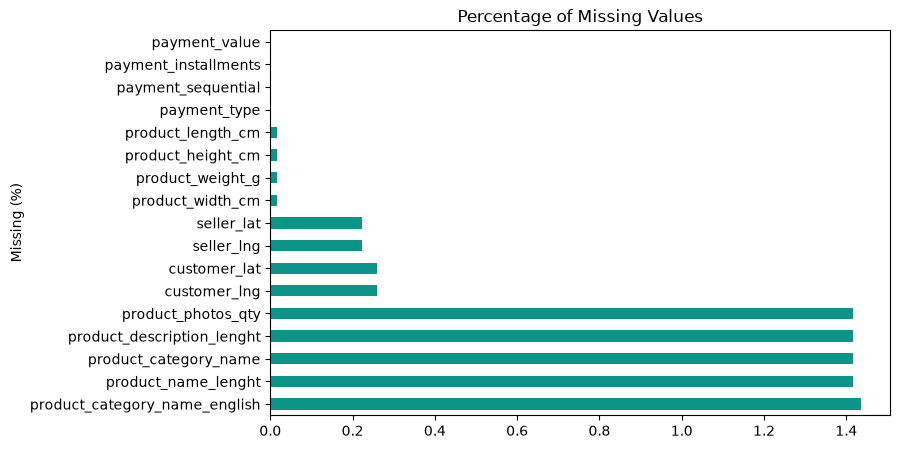

In [96]:
# Visualization of missing values in data
missing = df.isnull().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]

plt.figure(figsize=(8,5))
missing.plot(kind="barh", color='#0D9488')
plt.ylabel("Missing (%)")
plt.title("Percentage of Missing Values")
plt.savefig('../images/missing_values.png', bbox_inches='tight')
plt.show()

**Insight**
* Most missing data comes from product category that is around 1.4 percent of total records.

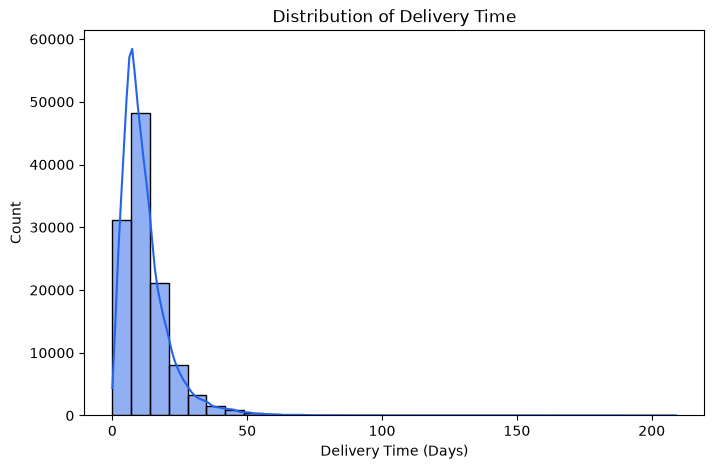

In [97]:
# How is the delivery time distributed?
plt.figure(figsize=(8,5))
sns.histplot(df["delivery_time_days"], bins=30, kde=True, color='#2563EB')
plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.savefig('../images/delivery_time_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* Delivery times are heavily right-skewed, with the vast majority of orders arriving within ten to twenty days.

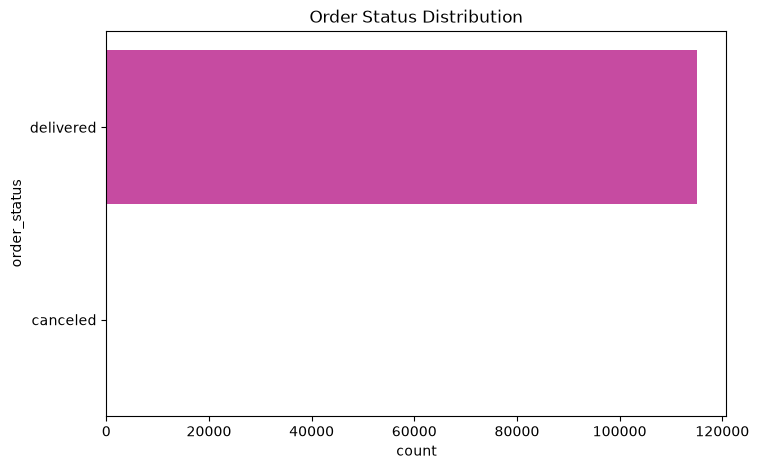

In [98]:
# Which order statuses are most common?
plt.figure(figsize=(8,5))
sns.countplot(y=df["order_status"], order=df["order_status"].value_counts().index, color="#DA37A9")
plt.title("Order Status Distribution")
plt.savefig('../images/order_status_distribution.png', bbox_inches='tight')
plt.show()

**Insight**
* Almost all orders in the dataset successfully reach the delivered status, with an extremely low cancellation rate.

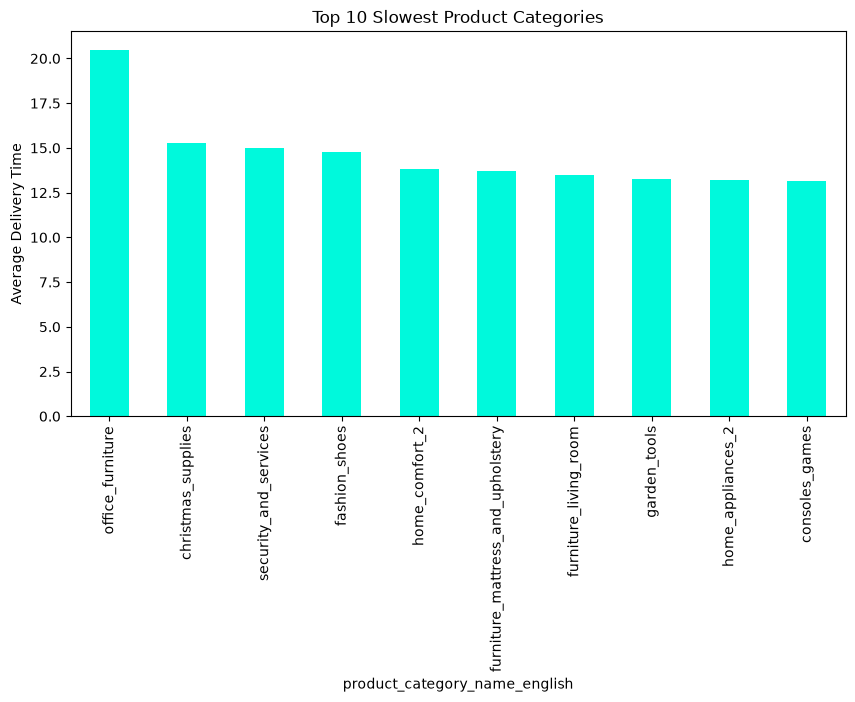

In [99]:
# Which product categories have the highest average delivery time?
top = (df.groupby("product_category_name_english")["delivery_time_days"]
         .mean()
         .sort_values(ascending=False)
         .head(10))

top.plot(kind="bar", figsize=(10,5), color="#00F9DC")
plt.ylabel("Average Delivery Time")
plt.title("Top 10 Slowest Product Categories")
plt.savefig('../images/top_10_slowest_product_delivery.png', bbox_inches='tight')
plt.show()

**Insight**
* Office furniture takes significantly longer to deliver than other categories, over twenty days per standard order.

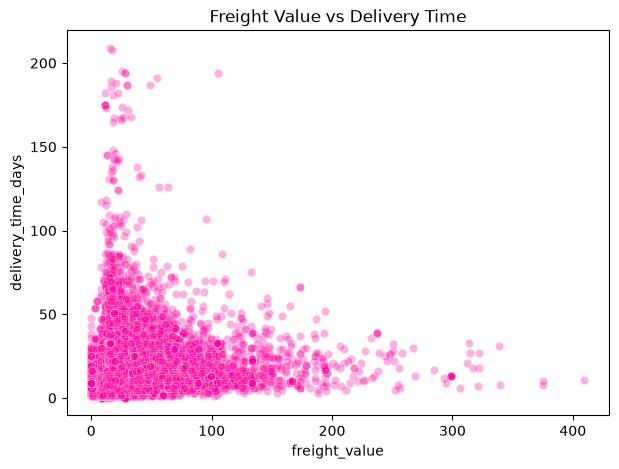

In [100]:
# Does freight cost (total fees charged by a carrier to transport goods) increase delivery time?
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="freight_value",
                y="delivery_time_days",
                alpha=0.3,
                color="#FE009D")
plt.title("Freight Value vs Delivery Time")
plt.savefig('../images/freight_value_vs_delivery_time.png', bbox_inches='tight')
plt.show()

**Insight**
* Higher freight costs does not guarantee faster deliveries, as many cheap shipments still experience extensive delays.

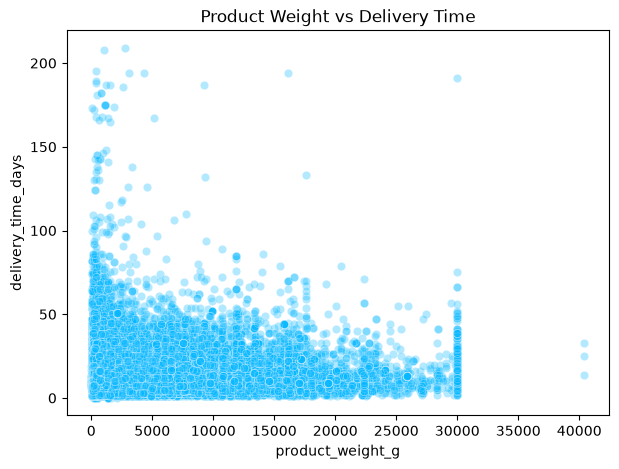

In [101]:
# Does product weight affect delivery time?
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="product_weight_g",
                y="delivery_time_days",
                alpha=0.3,
                color="#06B8FF")
plt.title("Product Weight vs Delivery Time")
plt.savefig('../images/product_weight_vs_delivery_time.png', bbox_inches='tight')
plt.show()

**Insight**
- Product weight shows no strong correlation with delivery time, meaning heavy items do not always arrive slower.

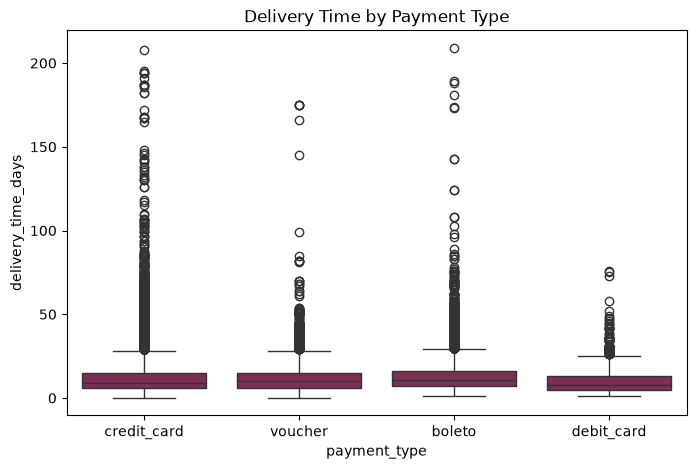

In [102]:
# Which payment method is associated with the longest delivery time?
plt.figure(figsize=(8,5))
sns.boxplot(data=df,
            x="payment_type",
            y="delivery_time_days",
            color='#882255')
plt.title("Delivery Time by Payment Type")
plt.savefig('../images/delivery_time_by_payment_status.png', bbox_inches='tight')
plt.show()

**Insight**
* Delivery speeds remained consistent across all payment methods, indicating payment type does not impacts the shipping duration.

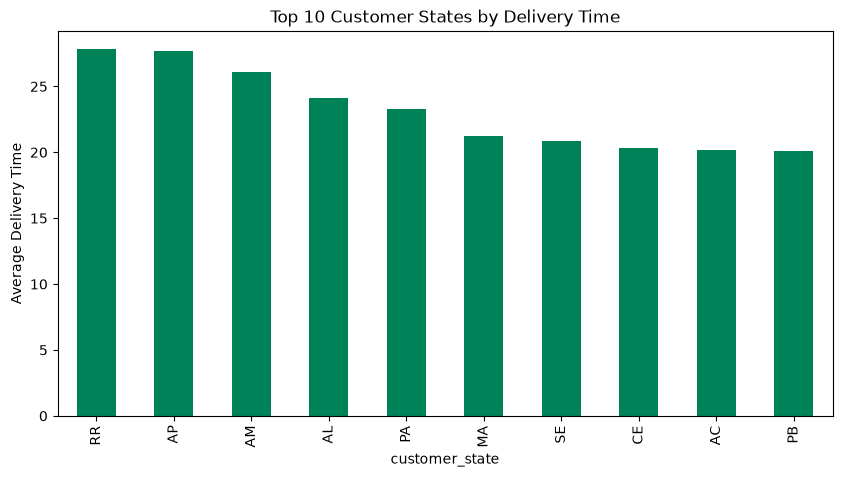

In [103]:
# Which customer states experience the longest average delivery time?
top = (df.groupby("customer_state")["delivery_time_days"]
         .mean()
         .sort_values(ascending=False)
         .head(10))

top.plot(kind="bar", figsize=(10,5), color="#008259")
plt.ylabel("Average Delivery Time")
plt.title("Top 10 Customer States by Delivery Time")
plt.savefig('../images/top_customer_states_by_delivery_time.png', bbox_inches='tight')
plt.show()

**Insight**
* Customers located in RR and AP experience the longest average wait times for deliveries.

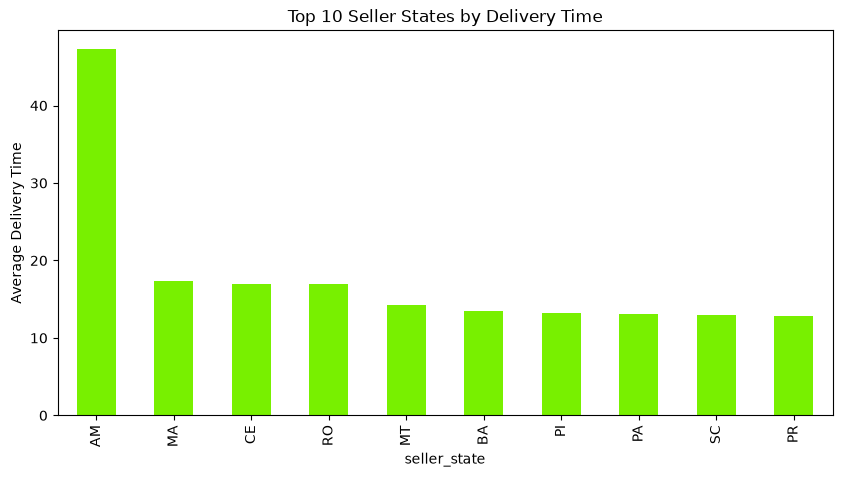

In [104]:
# Which seller states have the longest average delivery time?
top = (df.groupby("seller_state")["delivery_time_days"]
         .mean()
         .sort_values(ascending=False)
         .head(10))

top.plot(kind="bar", figsize=(10,5), color="#78F000")
plt.ylabel("Average Delivery Time")
plt.title("Top 10 Seller States by Delivery Time")
plt.savefig('../images/top_seller_states_by_delivery_time.png', bbox_inches='tight')
plt.show()

**Insight**
* Orders from AM experienced the highest delivery time

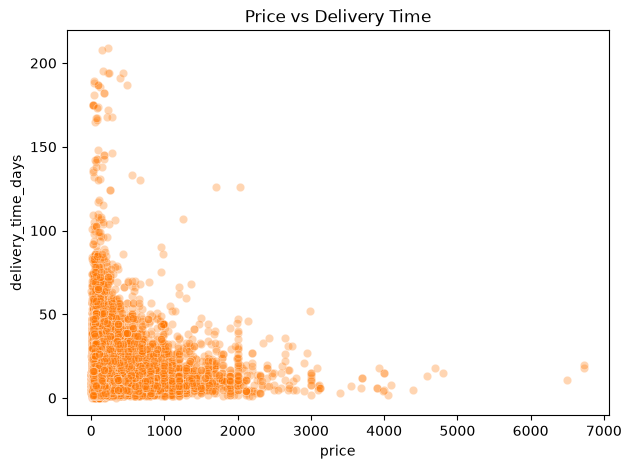

In [105]:
# Is there a relationship between price and delivery time?
plt.figure(figsize=(7,5))
sns.scatterplot(data=df,
                x="price",
                y="delivery_time_days",
                alpha=0.3,
                color="#FF7700")
plt.title("Price vs Delivery Time")
plt.savefig('../images/price_vs_delivery_time.png', bbox_inches='tight')
plt.show()

**Insight**
* Many cheap items have experienced a high delivery time as compared to expensive price 

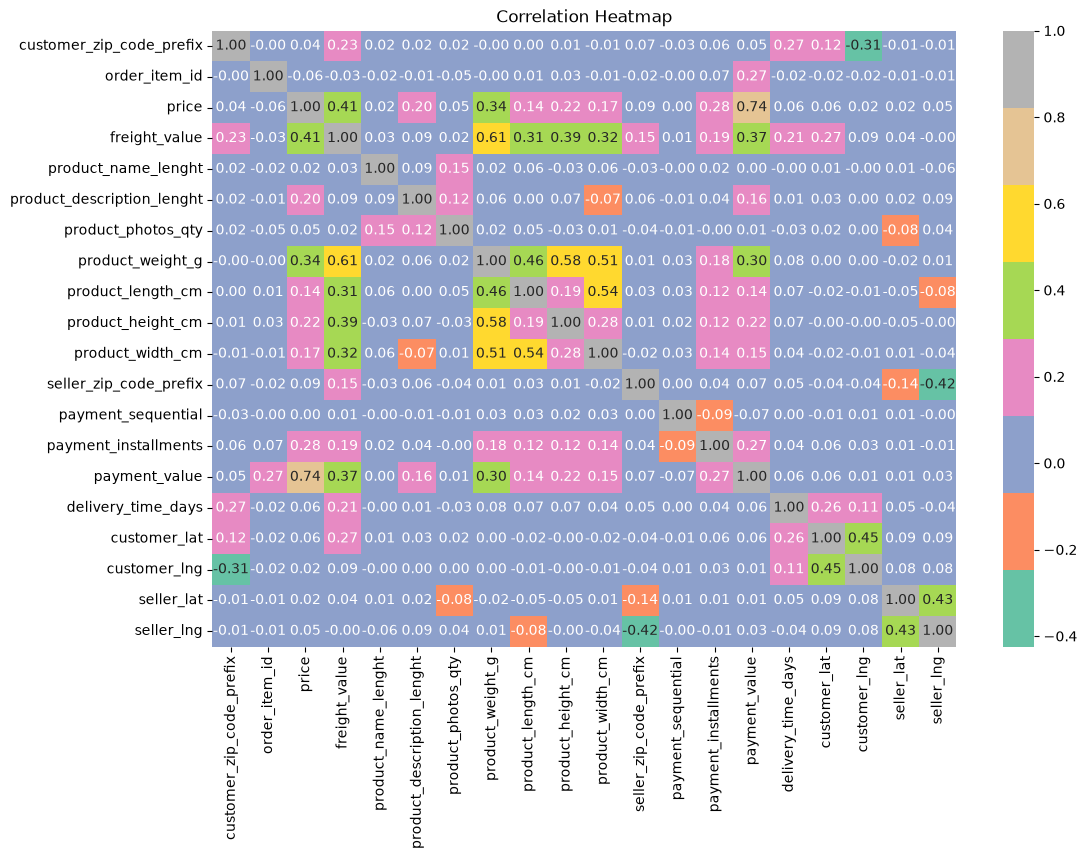

In [106]:
# Which numerical features are most correlated with delivery time?
numerical_columns = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))
sns.heatmap(numerical_columns.corr(),
            annot=True,
            cmap="Set2",
            fmt=".2f")
plt.title("Correlation Heatmap")
plt.savefig('../images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

## Data Cleaning

In [107]:
df.duplicated().sum()

np.int64(0)

In [108]:
df.dtypes

order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
customer_unique_id                   str
customer_zip_code_prefix           int64
customer_city                        str
customer_state                       str
order_item_id                    float64
product_id                           str
seller_id                            str
price                            float64
freight_value                    float64
product_category_name                str
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
seller_zip_code_prefix           float64
seller_city                          str
seller_state    

In [109]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
price                               0
freight_value                       0
product_category_name            1628
product_name_lenght              1628
product_description_lenght       1628
product_photos_qty               1628
product_weight_g                   20
product_length_cm                  20
product_height_cm                  20
product_width_cm                   20
product_category_name_english    1651
seller_zip_code_prefix              0
seller_city                         0
seller_state                        0
payment_sequential                  3
payment_type

In [110]:
# Filled product-related categorical missing values with unknown
df["product_category_name"] = df["product_category_name"].fillna("unknown")
df["product_category_name_english"] = df["product_category_name_english"].fillna("unknown")


In [111]:
# Filled product-related numerical missing values with median (robust to outliers)
numerical_columns = [
    "product_name_lenght",
    "product_description_lenght",
    "product_photos_qty"
]

for column in numerical_columns:
    df[column] = df[column].fillna(df[column].median())

In [112]:
# Filled product physical dimensions missing values with median (robust to outliers)
dimension_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in dimension_columns:
    df[column] = df[column].fillna(df[column].median())

In [113]:
# Dropped Payment information missing values because only 3 rows are missing in each
df = df.dropna(subset=[
    "payment_sequential",
    "payment_type",
    "payment_installments",
    "payment_value"
])

In [114]:
# Filled geolocation missing values with median (robust to outliers)
df["customer_lat"] = df["customer_lat"].fillna(df["customer_lat"].median())
df["customer_lng"] = df["customer_lng"].fillna(df["customer_lng"].median())

df["seller_lat"] = df["seller_lat"].fillna(df["seller_lat"].median())
df["seller_lng"] = df["seller_lng"].fillna(df["seller_lng"].median())

In [115]:
df.isnull().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
customer_unique_id               0
customer_zip_code_prefix         0
customer_city                    0
customer_state                   0
order_item_id                    0
product_id                       0
seller_id                        0
price                            0
freight_value                    0
product_category_name            0
product_name_lenght              0
product_description_lenght       0
product_photos_qty               0
product_weight_g                 0
product_length_cm                0
product_height_cm                0
product_width_cm                 0
product_category_name_english    0
seller_zip_code_prefix           0
seller_city                      0
seller_state                     0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value       

In [116]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id', 'price',
       'freight_value', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'seller_zip_code_prefix',
       'seller_city', 'seller_state', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'delivery_time_days',
       'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng'],
      dtype='str')

In [117]:
df['order_status'].value_counts()

order_status
delivered    115027
canceled          7
Name: count, dtype: int64

In [118]:
# Keeps only orders that are successfully delivered
df = df[df["order_status"] == "delivered"]

In [119]:
# Removed impossible values in delivery_time_days
df = df[df["delivery_time_days"] >= 0]
df['delivery_time_days'].describe()

count    115027.000000
mean         12.017778
std           9.458846
min           0.000000
25%           6.000000
50%          10.000000
75%          15.000000
max         209.000000
Name: delivery_time_days, dtype: float64

In [120]:
# Removed extreme delivery-time outliers (A 30-day delivery time can be normal for specific types of e-commerce orders)
df = df[df["delivery_time_days"] <= 30]

In [121]:
df['delivery_time_days'].describe()

count    110272.000000
mean         10.707387
std           6.280776
min           0.000000
25%           6.000000
50%           9.000000
75%          14.000000
max          30.000000
Name: delivery_time_days, dtype: float64

In [122]:
# Removed invalid monetary value
df = df[(df["price"] > 0) & (df["payment_value"] > 0)]

In [123]:
# Removed invalid physical dimensions
dimension_columns = [
    "product_weight_g",
    "product_length_cm",
    "product_height_cm",
    "product_width_cm"
]

for column in dimension_columns:
    df = df[df[column] > 0]

In [124]:
# Converted categorical text to consistent format
text_columns = [
    "customer_city", "seller_city",
    "customer_state", "seller_state",
    "payment_type", "product_category_name_english"
]

for column in text_columns:
    df[column] = df[column].astype(str).str.strip().str.lower()

In [125]:
# Changed order_purchase_timestamp dtype to datetime
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

## Feature Engineering

In [126]:
# Created time features from purchase timestamp
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour
df["purchase_day"] = df["order_purchase_timestamp"].dt.day
df["purchase_weekday"] = df["order_purchase_timestamp"].dt.weekday   # 0=Mon
df["purchase_month"] = df["order_purchase_timestamp"].dt.month

In [127]:
# Dropped order_purchase_timestamp because features have been extracted
df = df.drop(columns=["order_purchase_timestamp"])

In [128]:
# Orders from the same state might be delivered faster, so we created a new feature same_state
df['same_state'] = (df['customer_state'] == df['seller_state']).astype(int)

In [129]:
# Larger products takes more time to deliver, so we can create a new feature for product volume
df['product_volume'] = (df['product_length_cm'] * df['product_height_cm'] * df['product_width_cm'])

In [130]:
# Calculates distance between seller & customer using euclidean distance
df["geo_distance"] = np.sqrt(
    (df["customer_lat"] - df["seller_lat"])**2 +
    (df["customer_lng"] - df["seller_lng"])**2
)

In [131]:
# Dropped redundant columns because they are not useful for model training
redundant_columns = [ 
    "order_item_id",
    "order_id", 
    "customer_id", 
    "customer_unique_id", 
    "product_id", 
    "seller_id", 
    "product_category_name", 
    "customer_zip_code_prefix", 
    "seller_zip_code_prefix",
    "order_status",
    "customer_city",
    "customer_state",
    "seller_city",
    "seller_state"
    ] 

df = df.drop(columns=redundant_columns)

In [132]:
df.columns

Index(['price', 'freight_value', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'product_category_name_english', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'delivery_time_days',
       'customer_lat', 'customer_lng', 'seller_lat', 'seller_lng',
       'purchase_hour', 'purchase_day', 'purchase_weekday', 'purchase_month',
       'same_state', 'product_volume', 'geo_distance'],
      dtype='str')

In [133]:
df.dtypes

price                            float64
freight_value                    float64
product_name_lenght              float64
product_description_lenght       float64
product_photos_qty               float64
product_weight_g                 float64
product_length_cm                float64
product_height_cm                float64
product_width_cm                 float64
product_category_name_english        str
payment_sequential               float64
payment_type                         str
payment_installments             float64
payment_value                    float64
delivery_time_days               float64
customer_lat                     float64
customer_lng                     float64
seller_lat                       float64
seller_lng                       float64
purchase_hour                      int32
purchase_day                       int32
purchase_weekday                   int32
purchase_month                     int32
same_state                         int64
product_volume  

In [134]:
categorical_columns = df.select_dtypes(include="object").columns.tolist()
print(f'The dataset has {len(categorical_columns)} categorical columns: {categorical_columns}')

The dataset has 2 categorical columns: ['product_category_name_english', 'payment_type']


In [135]:
df['product_category_name_english'].value_counts()

product_category_name_english
bed_bath_table               11155
health_beauty                 9333
sports_leisure                8404
furniture_decor               8195
computers_accessories         7554
                             ...  
arts_and_craftmanship           24
la_cuisine                      16
cds_dvds_musicals               14
fashion_childrens_clothes        7
security_and_services            2
Name: count, Length: 72, dtype: int64

In [137]:
# Will do feature encoding after train test split to avoid data leakage
df[['product_category_name_english', 'payment_type']].nunique()

product_category_name_english    72
payment_type                      4
dtype: int64

## Model Training

In [138]:
# Splitting data into X and y
X = df.drop("delivery_time_days", axis=1)
y = df["delivery_time_days"]

In [139]:
# Train Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [140]:
# Feature Encoding
from sklearn.preprocessing import LabelEncoder
categorical_columns = X_train.select_dtypes(include='object').columns

for column in categorical_columns:
    le = LabelEncoder()
    X_train[column] = le.fit_transform(X_train[column].astype(str))
    X_test[column] = le.transform(X_test[column].astype(str))

In [141]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline Model Training

In [142]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "SVR": SVR(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
}

In [143]:
results = []

In [144]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
for name, model in models.items():

    if name in ["Linear Regression", "KNN", "SVR"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = root_mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    results.append([name, mae, rmse, r2])

baseline_results = pd.DataFrame(results,columns=["Model", "MAE", "RMSE", "R2"])
baseline_results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
4,Random Forest,3.118913,4.335278,0.527093
5,Gradient Boosting,3.725323,4.868176,0.403687
3,SVR,3.679279,5.068761,0.353535
1,KNN,3.930419,5.255432,0.305042
0,Linear Regression,4.146859,5.354833,0.278505
2,Decision Tree,4.044471,6.115393,0.058999


## Hyperparameter Tuning

**Linear Regression**

In [145]:
tuned_lr = LinearRegression()
tuned_lr.fit(X_train_scaled, y_train)
lr_pred = tuned_lr.predict(X_test_scaled)

print("Linear Regression")
print("R2:", r2_score(y_test, lr_pred))

Linear Regression
R2: 0.2785049681428212


**K Nearest Neighbor**

In [146]:
from sklearn.model_selection import GridSearchCV

knn_params = {
    "n_neighbors":[3,5,7,9,11],
    "weights":["uniform","distance"],
    "p":[1,2]
}

tuned_knn = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [147]:
tuned_knn.fit(X_train_scaled, y_train)
print(tuned_knn.best_params_)

{'n_neighbors': 11, 'p': 1, 'weights': 'distance'}


In [148]:
knn_best = tuned_knn.best_estimator_
knn_pred = knn_best.predict(X_test_scaled)
print("KNN R2:", r2_score(y_test, knn_pred))

KNN R2: 0.45220615986922685


**Decision Tree**

In [149]:
dt_params = {
    "max_depth":[5,10,15,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

tuned_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [150]:
tuned_dt.fit(X_train, y_train)
print(tuned_dt.best_params_)

{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [151]:
dt_best = tuned_dt.best_estimator_
dt_pred = dt_best.predict(X_test)
print("Decision Tree R2:", r2_score(y_test, dt_pred))

Decision Tree R2: 0.37296536079220954


**Random Forest**

In [152]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {
    "n_estimators":[100,200],
    "max_depth":[10,20,None],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}


tuned_rf = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=rf_params,
    n_iter=20,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

In [ ]:
tuned_rf.fit(X_train, y_train)
print(tuned_rf.best_params_)

In [ ]:
rf_best = tuned_rf.best_estimator_
rf_pred = rf_best.predict(X_test)
print("Random Forest R2:", r2_score(y_test, rf_pred))

**Gradient Boosting**

In [ ]:
gb_params = {
    "n_estimators":[100,200],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[3,5,7]
}

tuned_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

In [ ]:
tuned_gb.fit(X_train, y_train)
print(tuned_gb.best_params_)

In [ ]:
gb_best = tuned_gb.best_estimator_
gb_pred = gb_best.predict(X_test)
print("Gradient Boosting R2:", r2_score(y_test, gb_pred))

## Model comparison after hyperparameter tuning

In [ ]:
final_results = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
    ],

    "R2":[
        r2_score(y_test, lr_pred),
        r2_score(y_test, knn_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, gb_pred),
    ]
})

final_results.sort_values(by="R2",ascending=False)

In [ ]:
import joblib
joblib.dump(gb_best, "../model/delivery_time_model.pkl")